# Exploratory Data Analysis (EDA)

## What is EDA?

**Exploratory Data Analysis (EDA)** is the process of exploring, understanding, summarizing, and visualizing a dataset before building a machine learning model. Its primary goal is to discover patterns, identify anomalies, detect missing values and outliers, understand feature distributions, and uncover relationships between variables. EDA helps data scientists make informed decisions about data cleaning, feature engineering, and model selection.

---

## Types of Exploratory Data Analysis (EDA)

1. **Univariate Analysis**
2. **Bivariate Analysis**
3. **Multivariate Analysis**

# Univariate Analysis 
## All columns are Variable
## Analyse every column individually -> Univariate.
## Analyse 2 columns -> Bivariate
## Analyse mulltiple columns -> Multivariate

# Approach to Univariate Analysis

For each feature (column) in the dataset, perform the following steps:

1. Identify the data type.
   - Numerical
   - Categorical

2. Check for missing values.
   - Number and percentage of null values

3. Check for duplicate values (if relevant).

4. Find the number of unique values.

5. Analyze the distribution.
   - Numerical: Histogram, Density Plot
   - Categorical: Count Plot, Bar Chart

6. Calculate summary statistics.
   - Numerical:
     - Mean
     - Median
     - Mode
     - Minimum
     - Maximum
     - Standard Deviation
     - Quartiles
   - Categorical:
     - Frequency Count
     - Most Frequent Category

7. Detect outliers (Numerical only).
   - Box Plot
   - IQR Method

8. Check skewness (Numerical only).
   - Left Skewed
   - Right Skewed
   - Approximately Symmetric

9. Draw conclusions.
   - Missing values?
   - Outliers?
   - Skewed distribution?
   - Imbalanced categories?

In [13]:
import pandas as pd
import seaborn as sns
df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")

In [14]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 1. Categorial Data

## a. Countplot 

Survived
0    549
1    342
Name: count, dtype: int64

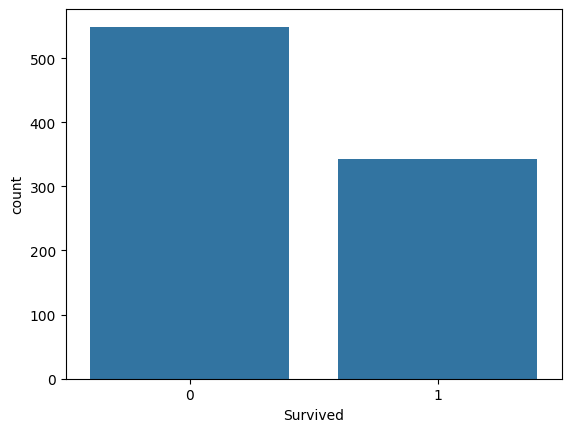

In [19]:
sns.countplot(data=df, x="Survived")
df["Survived"].value_counts()

<Axes: xlabel='Survived'>

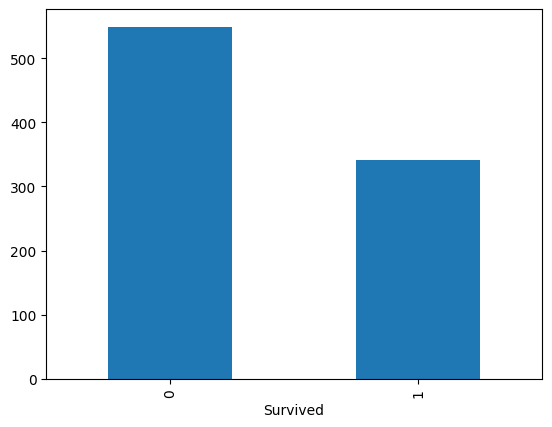

In [21]:
df["Survived"].value_counts().plot(kind="bar")  #THIS IS PANDAS

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

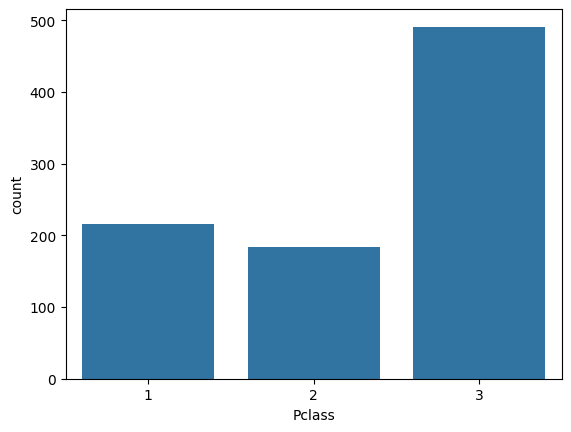

In [23]:
sns.countplot(data=df, x="Pclass")
df["Pclass"].value_counts()

<Axes: xlabel='Embarked', ylabel='count'>

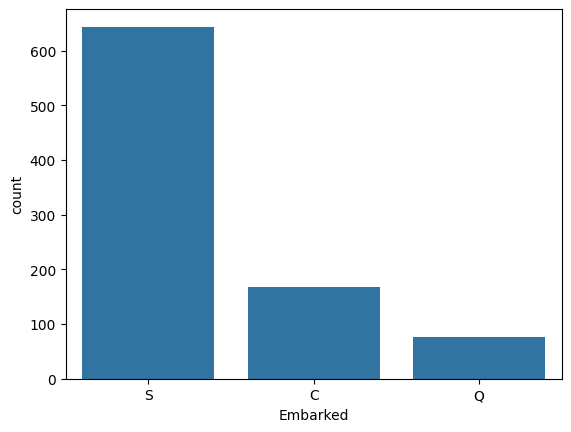

In [24]:
sns.countplot(data=df, x="Embarked")

##  b. PieChart

<Axes: ylabel='count'>

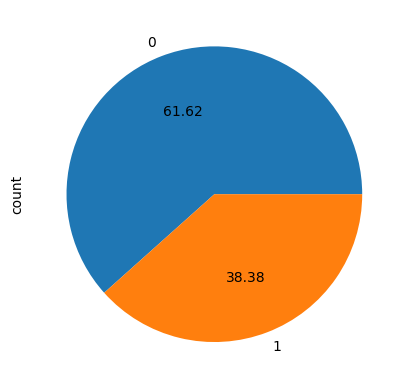

In [26]:
df["Survived"].value_counts().plot(kind="pie", autopct='%.2f')

# 2. Numerical Data

## a. Histogram  

In [27]:
import matplotlib.pyplot as plt;

(array([100., 346., 188.,  69.,  11.]),
 array([ 0.42 , 16.336, 32.252, 48.168, 64.084, 80.   ]),
 <BarContainer object of 5 artists>)

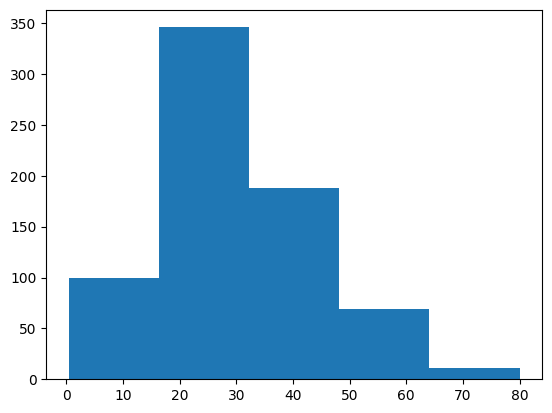

In [40]:
plt.hist(df["Age"], bins=5)   #Shows the number of people

## b. Displot

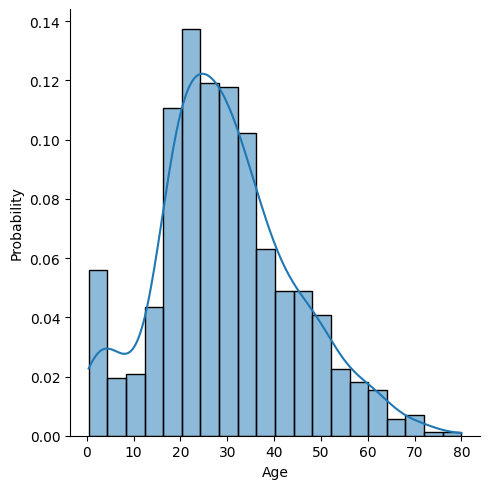

In [39]:
sns.displot(data=df, x="Age", kde=True, stat="probability") #Shows probability

In [49]:
df["Age"].skew()

np.float64(0.38910778230082704)

## c. Boxplot 

# Box Plot Terminology

### Quartiles

- **First Quartile (Q1)** (25th Percentile)

$$
Q_1 = \text{25th Percentile}
$$

- **Median (Q2)** (50th Percentile)

$$
Q_2 = \text{Median} = \text{50th Percentile}
$$

- **Third Quartile (Q3)** (75th Percentile)

$$
Q_3 = \text{75th Percentile}
$$

---

### Interquartile Range (IQR)

The Interquartile Range is the spread of the middle 50% of the data.

$$
\boxed{\text{IQR} = Q_3 - Q_1}
$$

---

### Lower Bound (Minimum Non-Outlier)

Any value smaller than this is considered an outlier.

$$
\boxed{\text{Lower Bound} = Q_1 - 1.5 \times \text{IQR}}
$$

---

### Upper Bound (Maximum Non-Outlier)

Any value larger than this is considered an outlier.

$$
\boxed{\text{Upper Bound} = Q_3 + 1.5 \times \text{IQR}}
$$

---

### Outlier Conditions

A data point is a **Lower Outlier** if

$$
x < Q_1 - 1.5 \times \text{IQR}
$$

A data point is an **Upper Outlier** if

$$
x > Q_3 + 1.5 \times \text{IQR}
$$

---

### Summary

$$
\begin{aligned}
Q_1 &= \text{25th Percentile} \\
Q_2 &= \text{Median (50th Percentile)} \\
Q_3 &= \text{75th Percentile} \\
\text{IQR} &= Q_3 - Q_1 \\
\text{Lower Bound} &= Q_1 - 1.5 \times \text{IQR} \\
\text{Upper Bound} &= Q_3 + 1.5 \times \text{IQR}
\end{aligned}
$$

<Axes: xlabel='Fare'>

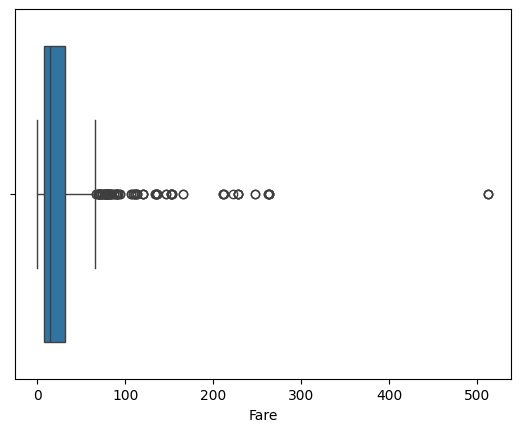

In [42]:
sns.boxplot(data=df, x="Fare")

<Axes: xlabel='Age'>

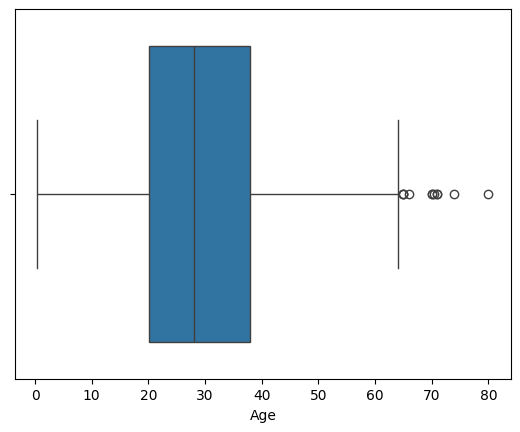

In [43]:
sns.boxplot(data=df, x="Age")

In [44]:
df["Age"].max()

80.0

In [45]:
df["Age"].min()

0.42

In [46]:
df["Age"].mean()

np.float64(29.69911764705882)

In [47]:
df["Age"].std()

14.526497332334044

# Distribution Shapes and Skewness

## 1. Normal Distribution

A Normal Distribution is a symmetric, bell-shaped distribution where the mean, median, and mode are equal.

$$
\boxed{\text{Mean} = \text{Median} = \text{Mode}}
$$

Characteristics:

- Bell-shaped
- Symmetric
- No skewness
- Mean ≈ Median ≈ Mode

Python:

```python
df['column'].hist()
sns.histplot(df['column'], kde=True)
```

---

## 2. Positively Skewed Distribution (Right Skew)

The tail extends toward the **right**.

$$
\boxed{\text{Mean} > \text{Median} > \text{Mode}}
$$

Characteristics:

- Long right tail
- Few very large values
- Most observations are small

Python:

```python
df['column'].skew()
```

Interpretation:

- Skewness > 0

---

## 3. Negatively Skewed Distribution (Left Skew)

The tail extends toward the **left**.

$$
\boxed{\text{Mean} < \text{Median} < \text{Mode}}
$$

Characteristics:

- Long left tail
- Few very small values
- Most observations are large

Python:

```python
df['column'].skew()
```

Interpretation:

- Skewness < 0

---

## 4. Symmetric Distribution

A distribution with equal tails on both sides.

$$
\boxed{\text{Skewness} \approx 0}
$$

Characteristics:

- Equal left and right tails
- Mean ≈ Median

Python:

```python
df['column'].skew()
```

---

# Skewness

Skewness measures the asymmetry of a distribution.

$$
\boxed{
\text{Skewness}=
\frac{\frac{1}{n}\sum (x_i-\bar{x})^3}
{\left(\frac{1}{n}\sum (x_i-\bar{x})^2\right)^{3/2}}
}
$$

Interpretation:

| Skewness | Interpretation |
|----------:|---------------|
| < -1 | Highly Left Skewed |
| -1 to -0.5 | Moderately Left Skewed |
| -0.5 to 0.5 | Approximately Symmetric |
| 0.5 to 1 | Moderately Right Skewed |
| > 1 | Highly Right Skewed |

Python:

```python
df['column'].skew()
```

or

```python
from scipy.stats import skew

skew(df['column'])
```

---

# Kurtosis

Kurtosis measures how heavy the tails are compared to a normal distribution.

Python:

```python
df['column'].kurt()
```

or

```python
from scipy.stats import kurtosis

kurtosis(df['column'])
```

Interpretation:

| Kurtosis | Distribution |
|----------:|-------------|
| < 0 | Platykurtic (Light Tails) |
| = 0 | Mesokurtic (Normal Distribution) |
| > 0 | Leptokurtic (Heavy Tails) |

---

# Mean

$$
\boxed{
\mu=\frac{\sum x_i}{n}
}
$$

Python:

```python
df['column'].mean()
```

---

# Median

Middle value after sorting.

$$
\boxed{
\text{Median}=Q_2
}
$$

Python:

```python
df['column'].median()
```

---

# Mode

Most frequently occurring value.

Python:

```python
df['column'].mode()
```

---

# Variance

Measures spread around the mean.

$$
\boxed{
\sigma^2=\frac{\sum (x_i-\mu)^2}{n}
}
$$

Python:

```python
df['column'].var()
```

---

# Standard Deviation

Measures average spread around the mean.

$$
\boxed{
\sigma=\sqrt{\sigma^2}
}
$$

Python:

```python
df['column'].std()
```

---

# Range

Difference between maximum and minimum values.

$$
\boxed{
\text{Range}=x_{\max}-x_{\min}
}
$$

Python:

```python
df['column'].max() - df['column'].min()
```

---

# Quartiles

$$
Q_1=\text{25th Percentile}
$$

$$
Q_2=\text{Median}
$$

$$
Q_3=\text{75th Percentile}
$$

Python:

```python
df['column'].quantile([0.25,0.5,0.75])
```

---

# Interquartile Range (IQR)

$$
\boxed{
IQR=Q_3-Q_1
}
$$

Python:

```python
Q1 = df['column'].quantile(0.25)
Q3 = df['column'].quantile(0.75)

IQR = Q3 - Q1
```

---

# Outlier Boundaries

Lower Bound

$$
Q_1-1.5\times IQR
$$

Upper Bound

$$
Q_3+1.5\times IQR
$$

Python:

```python
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
```

---

# Useful Python Functions for EDA

```python
df['column'].mean()
df['column'].median()
df['column'].mode()

df['column'].min()
df['column'].max()

df['column'].std()
df['column'].var()

df['column'].skew()
df['column'].kurt()

df['column'].quantile([0.25,0.5,0.75])

df['column'].describe()

sns.histplot(df['column'], kde=True)
sns.boxplot(x=df['column'])

df['column'].value_counts()
df['column'].unique()
df['column'].nunique()
```